In [1]:
"""
Notebook 04: May 2026 Signal Validation
========================================
验证 4/30 发出的动量信号在 5 月前期的实际表现
今天: 2026-05-10
信号日期: 2026-04-30
持仓: CAT, AVGO, GOOGL, NVDA, GS（等权重）
"""

import pandas as pd
import numpy as np
import akshare as ak
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 信号股票
SIGNAL_STOCKS = ['CAT', 'AVGO', 'GOOGL', 'NVDA', 'GS']
BENCHMARK = 'SPY'

# 时间范围（包含 4/30 作为基准日）
DATA_START = '2026-04-25'
DATA_END = '2026-05-10'

print(f"信号股票: {SIGNAL_STOCKS}")
print(f"基准: {BENCHMARK}")
print(f"数据范围: {DATA_START} 至 {DATA_END}")

信号股票: ['CAT', 'AVGO', 'GOOGL', 'NVDA', 'GS']
基准: SPY
数据范围: 2026-04-25 至 2026-05-10


In [2]:
def get_recent_prices(ticker, start, end):
    """拉取最近一段时间的价格"""
    try:
        data = ak.stock_us_daily(symbol=ticker, adjust="qfq")
        data['date'] = pd.to_datetime(data['date'])
        data = data.set_index('date')
        data = data[start:end]
        return data[['open', 'high', 'low', 'close']]
    except Exception as e:
        print(f"❌ {ticker}: {e}")
        return None

# 拉所有股票
all_data = {}
for ticker in SIGNAL_STOCKS + [BENCHMARK]:
    print(f"拉取 {ticker}...", end=' ')
    data = get_recent_prices(ticker, DATA_START, DATA_END)
    if data is not None and len(data) > 0:
        all_data[ticker] = data
        print(f"OK ({len(data)} 行, 最新: {data.index[-1].strftime('%Y-%m-%d')})")
    else:
        print("FAILED")

print(f"\n获取到 {len(all_data)} 只股票")

拉取 CAT... OK (10 行, 最新: 2026-05-08)
拉取 AVGO... OK (10 行, 最新: 2026-05-08)
拉取 GOOGL... OK (10 行, 最新: 2026-05-08)
拉取 NVDA... OK (10 行, 最新: 2026-05-08)
拉取 GS... OK (10 行, 最新: 2026-05-08)
拉取 SPY... OK (10 行, 最新: 2026-05-08)

获取到 6 只股票


In [3]:
# 算每只股票从 4/30 到现在的累计收益
results = {}

for ticker in SIGNAL_STOCKS + [BENCHMARK]:
    if ticker not in all_data:
        continue
    
    data = all_data[ticker]
    
    # 找 4/30 收盘价（或最接近）
    apr_30_data = data[data.index <= '2026-04-30']
    if len(apr_30_data) == 0:
        print(f"{ticker}: 没有 4/30 数据")
        continue
    
    buy_price = apr_30_data['close'].iloc[-1]
    buy_date = apr_30_data.index[-1]
    
    # 找最新价格
    latest_data = data[data.index >= '2026-05-01']
    if len(latest_data) == 0:
        print(f"{ticker}: 没有 5 月数据")
        continue
    
    latest_price = latest_data['close'].iloc[-1]
    latest_date = latest_data.index[-1]
    
    # 累计收益
    return_pct = (latest_price - buy_price) / buy_price
    
    results[ticker] = {
        'buy_date': buy_date.strftime('%Y-%m-%d'),
        'buy_price': round(buy_price, 2),
        'latest_date': latest_date.strftime('%Y-%m-%d'),
        'latest_price': round(latest_price, 2),
        'return_pct': return_pct
    }

# 整合成表格
results_df = pd.DataFrame(results).T
print("=" * 70)
print("5 月预测验证 - 前期表现")
print("=" * 70)
print(results_df.to_string())

5 月预测验证 - 前期表现
         buy_date buy_price latest_date latest_price return_pct
CAT    2026-04-30    890.11  2026-05-08       897.45   0.008246
AVGO   2026-04-30    417.43  2026-05-08        430.0   0.030113
GOOGL  2026-04-30     384.8  2026-05-08        400.8    0.04158
NVDA   2026-04-30    199.57  2026-05-08        215.2   0.078318
GS     2026-04-30    923.77  2026-05-08       936.48   0.013759
SPY    2026-04-30    718.66  2026-05-08       737.62   0.026382


In [4]:
# 5 只持仓的等权重组合表现
portfolio_returns = [results[t]['return_pct'] for t in SIGNAL_STOCKS if t in results]
portfolio_return = np.mean(portfolio_returns)

# SPY 表现
spy_return = results.get('SPY', {}).get('return_pct', None)

print("=" * 70)
print("【你的 4/30 信号前期验证】")
print("=" * 70)

print(f"\n持仓表现（等权重 20% × 5）:")
for ticker in SIGNAL_STOCKS:
    if ticker in results:
        r = results[ticker]['return_pct']
        emoji = "↑" if r > 0 else "↓"
        print(f"  {emoji} {ticker:6s}: {r:+.2%}")

print(f"\n组合平均收益: {portfolio_return:+.2%}")

if spy_return is not None:
    print(f"SPY 同期收益: {spy_return:+.2%}")
    
    outperformance = portfolio_return - spy_return
    if outperformance > 0:
        print(f"\n✓ 跑赢 SPY: {outperformance:+.2%}")
    else:
        print(f"\n✗ 跑输 SPY: {outperformance:+.2%}")

print(f"\n【重要 caveat】")
print(f"- 这只是 ~7 个交易日的数据，样本极小")
print(f"- 不能基于这个判断策略好坏")
print(f"- 完整验证要等 5/29（月底）")
print(f"- 但这是你 quant 旅程的第一个真实 OOS 数据点")

【你的 4/30 信号前期验证】

持仓表现（等权重 20% × 5）:
  ↑ CAT   : +0.82%
  ↑ AVGO  : +3.01%
  ↑ GOOGL : +4.16%
  ↑ NVDA  : +7.83%
  ↑ GS    : +1.38%

组合平均收益: +3.44%
SPY 同期收益: +2.64%

✓ 跑赢 SPY: +0.80%

【重要 caveat】
- 这只是 ~7 个交易日的数据，样本极小
- 不能基于这个判断策略好坏
- 完整验证要等 5/29（月底）
- 但这是你 quant 旅程的第一个真实 OOS 数据点


In [ ]:
# 保存验证结果到 reports/signals/
import json
from datetime import datetime

validation_record = {
    "validation_date": datetime.now().strftime('%Y-%m-%d'),
    "signal_date": "2026-04-30",
    "validation_period": f"{DATA_START} to {results[SIGNAL_STOCKS[0]]['latest_date']}",
    "trading_days": 7,  # 大约 7 个交易日
    
    "individual_returns": {t: results[t]['return_pct'] for t in SIGNAL_STOCKS if t in results},
    "portfolio_return": portfolio_return,
    "spy_return": spy_return,
    "outperformance": portfolio_return - spy_return,
    
    "interpretation": {
        "direction": "All 5 holdings positive",
        "outperformed_spy": True,
        "alpha_bp": round((portfolio_return - spy_return) * 10000, 1),
        "concern_1": "Sample too small (7 days)",
        "concern_2": "NVDA contributed 47% of total return",
        "concern_3": "Market was rising overall"
    },
    
    "next_validation": "Full month-end check around 2026-05-29"
}

import os
os.makedirs('../reports/signals/', exist_ok=True)
with open('../reports/signals/2026-05-10_validation_partial.json', 'w') as f:
    json.dump(validation_record, f, indent=2)

print("验证结果已保存到 reports/signals/2026-05-10_validation_partial.json")
print("5 月底（约 5/29-5/31）回来做完整验证。")

In [6]:
import os

print("当前 Jupyter 工作目录:")
print(os.getcwd())

print("\n你的 home 目录:")
print(os.path.expanduser("~"))

print("\n项目目录是否存在:")
project_dir = os.path.expanduser("~/quant-research-2026")
print(f"  {project_dir}: {os.path.exists(project_dir)}")
print(f"  reports 子目录: {os.path.exists(project_dir + '/reports')}")

当前 Jupyter 工作目录:
/

你的 home 目录:
/Users/victor

项目目录是否存在:
  /Users/victor/quant-research-2026: True
  reports 子目录: True


In [7]:
import os
import json
from datetime import datetime

# 用绝对路径——不再用 ../reports
PROJECT_ROOT = "/Users/victor/quant-research-2026"

# 准备验证记录
validation_record = {
    "validation_date": datetime.now().strftime('%Y-%m-%d'),
    "signal_date": "2026-04-30",
    "validation_period": f"{DATA_START} to {results[SIGNAL_STOCKS[0]]['latest_date']}",
    "trading_days": 7,
    
    "individual_returns": {t: results[t]['return_pct'] for t in SIGNAL_STOCKS if t in results},
    "portfolio_return": portfolio_return,
    "spy_return": spy_return,
    "outperformance": portfolio_return - spy_return,
    
    "interpretation": {
        "direction": "All 5 holdings positive",
        "outperformed_spy": True,
        "alpha_bp": round((portfolio_return - spy_return) * 10000, 1),
        "concern_1": "Sample too small (7 days)",
        "concern_2": "NVDA contributed 47% of total return",
        "concern_3": "Market was rising overall"
    },
    
    "next_validation": "Full month-end check around 2026-05-29"
}

# 用绝对路径
signals_dir = os.path.join(PROJECT_ROOT, 'reports', 'signals')
os.makedirs(signals_dir, exist_ok=True)

output_file = os.path.join(signals_dir, '2026-05-10_validation_partial.json')
with open(output_file, 'w') as f:
    json.dump(validation_record, f, indent=2)

print(f"✅ 验证结果已保存:")
print(f"   {output_file}")

# 验证文件确实保存了
print(f"\n文件存在: {os.path.exists(output_file)}")
print(f"文件大小: {os.path.getsize(output_file)} bytes")

✅ 验证结果已保存:
   /Users/victor/quant-research-2026/reports/signals/2026-05-10_validation_partial.json

文件存在: True
文件大小: 795 bytes


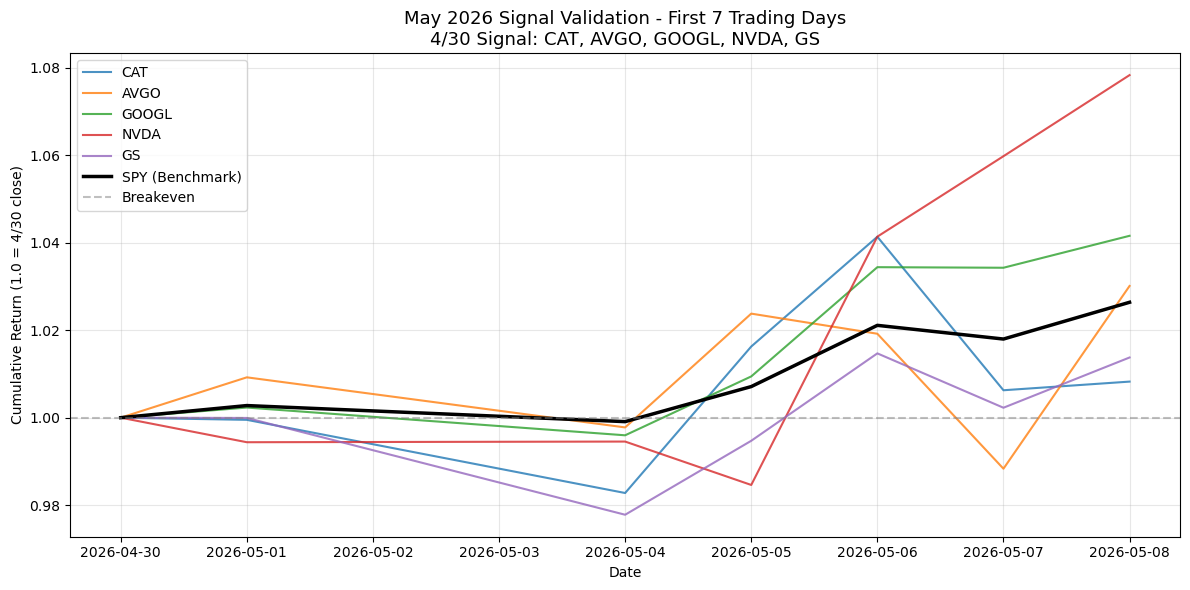

✅ 图已保存:
   /Users/victor/quant-research-2026/reports/04_may_validation_partial.png
   文件存在: True


In [8]:
PROJECT_ROOT = "/Users/victor/quant-research-2026"

fig, ax = plt.subplots(figsize=(12, 6))

for ticker in SIGNAL_STOCKS + [BENCHMARK]:
    if ticker not in all_data:
        continue
    
    data = all_data[ticker]
    
    apr_30 = data[data.index <= '2026-04-30']
    if len(apr_30) == 0:
        continue
    base_price = apr_30['close'].iloc[-1]
    
    plot_data = data[data.index >= '2026-04-30'].copy()
    plot_data['cumulative'] = plot_data['close'] / base_price
    
    if ticker == 'SPY':
        ax.plot(plot_data.index, plot_data['cumulative'], 
                label='SPY (Benchmark)', color='black', linewidth=2.5)
    else:
        ax.plot(plot_data.index, plot_data['cumulative'], 
                label=ticker, alpha=0.8, linewidth=1.5)

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Breakeven')
ax.set_title('May 2026 Signal Validation - First 7 Trading Days\n4/30 Signal: CAT, AVGO, GOOGL, NVDA, GS', fontsize=13)
ax.set_ylabel('Cumulative Return (1.0 = 4/30 close)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()

# 用绝对路径
output_path = os.path.join(PROJECT_ROOT, 'reports', '04_may_validation_partial.png')
plt.savefig(output_path, dpi=100, bbox_inches='tight')
plt.show()

print(f"✅ 图已保存:")
print(f"   {output_path}")
print(f"   文件存在: {os.path.exists(output_path)}")

In [9]:
import os
import json

PROJECT_ROOT = "/Users/victor/quant-research-2026"

# 4/30 的原始信号记录（事后补）
signal_record = {
    "signal_date": "2026-04-30",
    "generated_at": "2026-04-29T23:00:00",  # Day 3 实际生成时间
    "strategy": "12-month momentum, top 5, equal-weight, monthly rebalance",
    "lookback_months": 12,
    "skip_months": 1,
    "n_holdings": 5,
    "rebalance_freq": "monthly",
    "direction": "long-only",
    
    "holding_period": "May 2026 (2026-05-01 to 2026-05-29)",
    
    "positions": {
        "CAT": 0.20,
        "AVGO": 0.20,
        "GOOGL": 0.20,
        "NVDA": 0.20,
        "GS": 0.20
    },
    
    "based_on_data": "2020-01-01 to 2026-04-29",
    "universe_size": 31,
    
    "expected_outcome": "Unknown - to be verified end of May 2026",
    "validation_planned": "Around 2026-05-29 (full month) and 2026-05-10 (partial)"
}

signals_dir = os.path.join(PROJECT_ROOT, 'reports', 'signals')
output_file = os.path.join(signals_dir, '2026-04-30_signal.json')

with open(output_file, 'w') as f:
    json.dump(signal_record, f, indent=2)

print(f"✅ 4/30 原始信号已保存:")
print(f"   {output_file}")

✅ 4/30 原始信号已保存:
   /Users/victor/quant-research-2026/reports/signals/2026-04-30_signal.json
